# Experiment 2: Baseline Model + Experiment Tracking

**Student:** Yuvraj Gandhi &nbsp;|&nbsp; **Roll No:** 23101C0059 &nbsp;|&nbsp; **Branch:** INFT - C
**Subject:** Deep Learning Lab (PEIT37P) &nbsp;|&nbsp; **Dataset:** MNIST

**Aim:** Build and train a baseline Artificial Neural Network (ANN) on the MNIST handwritten
digit dataset, and track experiments manually across multiple hyperparameter configurations to
ensure reproducibility and comparability of results.

In [1]:
import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)
Path("../models").mkdir(exist_ok=True)

tf.random.set_seed(42)
np.random.seed(42)

## Step 1 — Load the MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print(X_train.shape, X_test.shape)

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/11490434 ━━━━━━━━━━━━━━━━━━━━ 44s 4us/step

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:31 8us/step

   81920/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:14 7us/step

  114688/11490434 ━━━━━━━━━━━━━━━━━━━━ 59s 5us/step 

...

 9781248/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

10665984/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11304960/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


(60000, 28, 28) (10000, 28, 28)


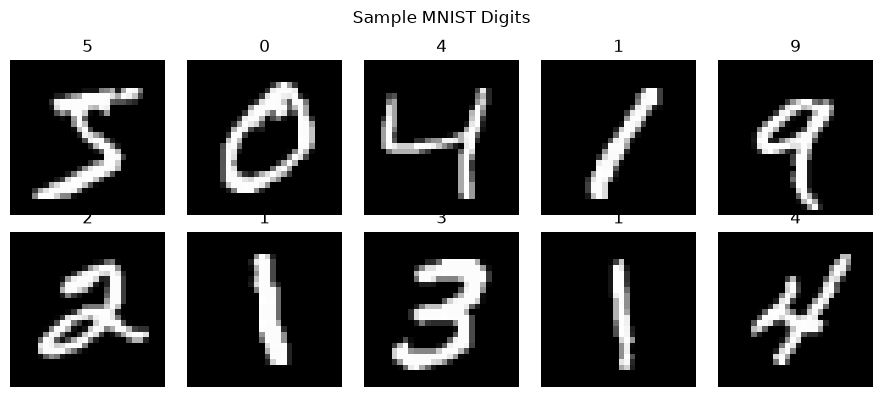

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(str(y_train[i]))
    ax.axis("off")
plt.suptitle("Sample MNIST Digits")
plt.tight_layout()
plt.savefig(FIGURES / "01_sample_digits.png", dpi=150)
plt.show()

## Step 2 & 3 — Normalize and Flatten

In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

print(X_train.shape)

(60000, 784)


## Step 4 & 5 — Build and Compile a Baseline ANN

In [5]:
def build_model(lr=0.001):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


build_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6 — Manual Experiment Tracking

In [6]:
experiment_log = []
histories = {}


def run_experiment(exp_id, lr, epochs, batch_size):
    model = build_model(lr)
    start = datetime.datetime.now()

    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    duration = (datetime.datetime.now() - start).total_seconds()

    experiment_log.append({
        "exp_id": exp_id,
        "learning_rate": lr,
        "epochs": epochs,
        "batch_size": batch_size,
        "val_accuracy": round(max(history.history["val_accuracy"]), 4),
        "test_accuracy": round(test_acc, 4),
        "training_time_sec": round(duration, 2),
    })
    histories[exp_id] = history
    return model

## Step 6 (cont.) — Run Multiple Configurations

In [7]:
run_experiment("EXP-01", lr=0.001, epochs=10, batch_size=32)
run_experiment("EXP-02", lr=0.01, epochs=10, batch_size=32)
run_experiment("EXP-03", lr=0.0001, epochs=10, batch_size=64)

log_df = pd.DataFrame(experiment_log)
log_df.to_csv("../experiment_log.csv", index=False)
print(log_df)

   exp_id  learning_rate  epochs  batch_size  val_accuracy  test_accuracy  \
0  EXP-01         0.0010      10          32        0.9797         0.9779   
1  EXP-02         0.0100      10          32        0.9657         0.9592   
2  EXP-03         0.0001      10          64        0.9708         0.9636   

   training_time_sec  
0              48.21  
1              50.27  
2              28.62  


## Step 7 & 8 — Compare Configurations

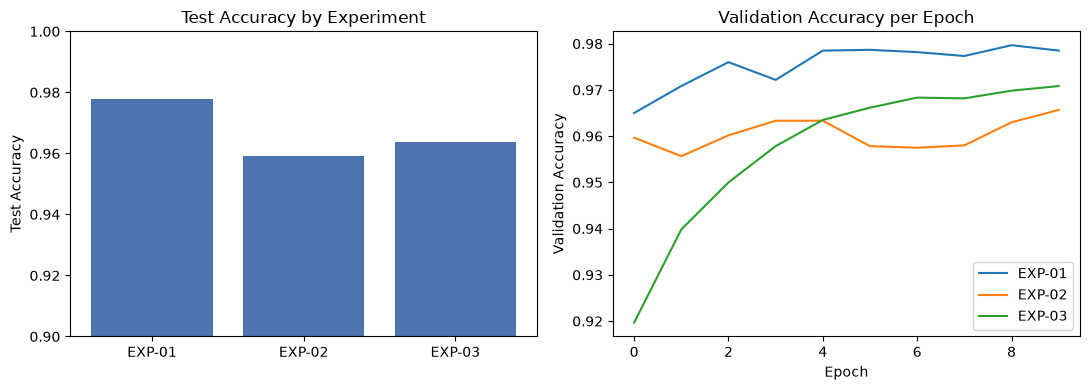

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(log_df["exp_id"], log_df["test_accuracy"], color="#4C72B0")
axes[0].set_title("Test Accuracy by Experiment")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_ylim(0.9, 1.0)

for exp_id, history in histories.items():
    axes[1].plot(history.history["val_accuracy"], label=exp_id)
axes[1].set_title("Validation Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / "02_experiment_comparison.png", dpi=150)
plt.show()

In [9]:
best_exp = log_df.loc[log_df["test_accuracy"].idxmax()]
print("Best configuration:\n", best_exp)

best_model = run_experiment(
    "BEST-REFIT", best_exp["learning_rate"], int(best_exp["epochs"]), int(best_exp["batch_size"])
)
best_model.save("../models/baseline_ann.h5")
print("Baseline model trained successfully")
print("Results saved to experiment_log.csv")

Best configuration:
 exp_id               EXP-01
learning_rate         0.001
epochs                   10
batch_size               32
val_accuracy         0.9797
test_accuracy        0.9779
training_time_sec     48.21
Name: 0, dtype: object


Baseline model trained successfully
Results saved to experiment_log.csv


## Conclusion

A baseline ANN model was successfully trained on the MNIST dataset. Three hyperparameter
configurations (varying learning rate and batch size) were tracked manually using a structured
`experiment_log.csv`, enabling direct comparison of configurations. This process established a
reproducible reference point for future model development and demonstrated the value of
systematic experiment tracking in a deep learning workflow.